# W2D3: Handling Imbalanced Data — SMOTE

## Objective

To handle imbalanced classification data using SMOTE (Synthetic Minority Over-sampling Technique).

## Tasks

- Create an imbalanced dataset
- Check class distribution
- Split data into training and testing sets
- Apply SMOTE only to training data
- Train a machine learning model
- Evaluate the model
- Test the SMOTE implementation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Create an imbalanced classification dataset

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    weights=[0.90, 0.10],
    random_state=42
)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (1000, 6)
Target shape: (1000,)


In [4]:
# Check the distribution of the target classes

class_counts = pd.Series(y).value_counts().sort_index()

print("Class distribution before SMOTE:")
print(class_counts)

Class distribution before SMOTE:
0    895
1    105
Name: count, dtype: int64


In [5]:
# Split the dataset into training and testing sets
# SMOTE will be applied only to the training data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (800, 6)
Testing data: (200, 6)
Training labels: (800,)
Testing labels: (200,)


In [6]:
# Apply SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Training data before SMOTE:", X_train.shape)
print("Training data after SMOTE:", X_train_smote.shape)

Training data before SMOTE: (800, 6)
Training data after SMOTE: (1432, 6)


In [7]:
# Check class distribution after applying SMOTE

smote_counts = pd.Series(y_train_smote).value_counts().sort_index()

print("Class distribution after SMOTE:")
print(smote_counts)

Class distribution after SMOTE:
0    716
1    716
Name: count, dtype: int64


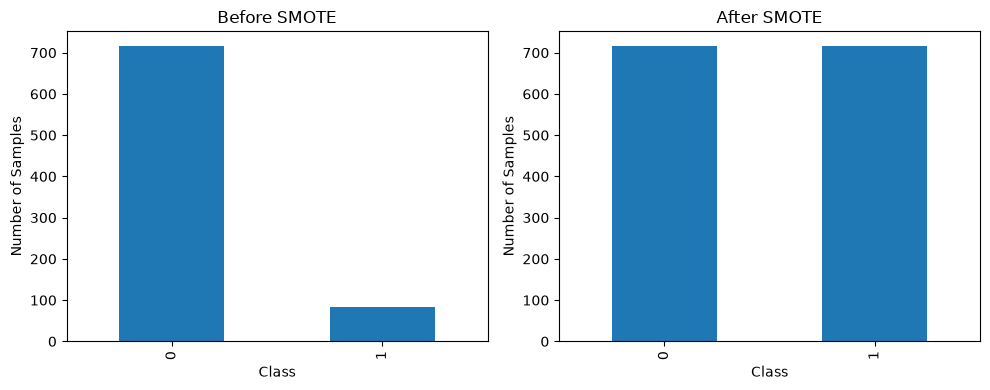

In [8]:
# Visualize class distribution before and after SMOTE

before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_smote).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before.plot(kind="bar", ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")

after.plot(kind="bar", ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

In [9]:
# Train a Random Forest classifier using the SMOTE-balanced data

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
# Make predictions on the original test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 200


In [11]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.92
Model Accuracy (%): 92.0 %


In [12]:
# Display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[170   9]
 [  7  14]]


In [13]:
# Generate a detailed classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       179
           1       0.61      0.67      0.64        21

    accuracy                           0.92       200
   macro avg       0.78      0.81      0.80       200
weighted avg       0.92      0.92      0.92       200



In [14]:
# Test 1: Verify that SMOTE balances the two classes

class_counts = pd.Series(y_train_smote).value_counts()

assert class_counts.iloc[0] == class_counts.iloc[1], \
    "Test failed: Classes are not balanced."

print("TEST 1 PASSED: SMOTE balanced the training classes.")

TEST 1 PASSED: SMOTE balanced the training classes.


In [15]:
# Test 2: Verify that the model produces predictions

assert len(y_pred) == len(y_test), \
    "Test failed: Prediction count does not match test data."

print("TEST 2 PASSED: Prediction count matches test data.")

TEST 2 PASSED: Prediction count matches test data.


In [16]:
# Test 3: Verify that the model achieved reasonable accuracy

assert 0 <= accuracy <= 1, \
    "Test failed: Accuracy is outside the valid range."

print("TEST 3 PASSED: Accuracy is within the valid range.")

TEST 3 PASSED: Accuracy is within the valid range.


In [17]:
print("=" * 50)
print("SMOTE PROJECT TEST SUMMARY")
print("=" * 50)
print("✓ SMOTE class balancing test passed")
print("✓ Prediction count test passed")
print("✓ Accuracy validation test passed")
print("=" * 50)
print("All tests passed successfully!")

SMOTE PROJECT TEST SUMMARY
✓ SMOTE class balancing test passed
✓ Prediction count test passed
✓ Accuracy validation test passed
All tests passed successfully!
